# 2STAT

On étudie quatre fichiers mensuels :
- ch4_mm_gl.csv (méthane)
- co2_mm_mlo.csv (CO2)
- n2o_mm_gl.csv (protoxyde d'azote)
- sf6_mm_gl.csv (hexafluorure de soufre)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# dossier ou se trouvent les fichiers CSV
dossier_donnees = Path("data")


def calculer_regression_lineaire(abscisses, ordonnees):
    """Calcule la droite y = ordonnee_a_l_origine + pente * x et le coefficient de corrélation."""
    pente, ordonnee_a_l_origine = np.polyfit(abscisses, ordonnees, 1)
    coefficient_correlation = np.corrcoef(abscisses, ordonnees)[0, 1]
    return ordonnee_a_l_origine, pente, coefficient_correlation


## Question 1 et 2 Chargement des données

On charge les 4 fichiers.
On garde que les colonnes month (mois) et average (concentration moyenne).


In [19]:
noms_fichiers = {
    "CH4": "ch4_mm_gl.csv",
    "CO2": "co2_mm_mlo.csv",
    "N2O": "n2o_mm_gl.csv",
    "SF6": "sf6_mm_gl.csv",
}

unites_mesure = {
    "CH4": "ppb",
    "CO2": "ppm",
    "N2O": "ppb",
    "SF6": "ppt",
}

#tableaux mensuels (month + average uniquement)
donnees_par_gaz = {}

# tableaux complet (avec year, etc)
donnees_completes_par_gaz = {}

#résumé dans un tableau
lignes_resume = []

for nom_du_gaz, nom_fichier in noms_fichiers.items():
    tableau_complet = pd.read_csv(
        dossier_donnees / nom_fichier,
        comment="#",
        skipinitialspace=True,
    )
    tableau_complet.columns = [
        nom_colonne.strip().replace("decimal date", "decimal")
        for nom_colonne in tableau_complet.columns
    ]
    donnees_completes_par_gaz[nom_du_gaz] = tableau_complet

    date_debut = (
        str(int(tableau_complet["year"].iloc[0]))
        + "-"
        + str(int(tableau_complet["month"].iloc[0])).zfill(2)
    )
    date_fin = (
        str(int(tableau_complet["year"].iloc[-1]))
        + "-"
        + str(int(tableau_complet["month"].iloc[-1])).zfill(2)
    )

    lignes_resume.append(
        {
            "gaz": nom_du_gaz,
            "fichier": nom_fichier,
            "nombre_observations": len(tableau_complet),
            "periode_debut": date_debut,
            "periode_fin": date_fin,
            "unite": unites_mesure[nom_du_gaz],
            "concentration_min": round(tableau_complet["average"].min(), 2),
            "concentration_max": round(tableau_complet["average"].max(), 2),
        }
    )

    tableau_mensuel = tableau_complet[["month", "average"]].copy()
    tableau_mensuel.index = range(1, len(tableau_mensuel) + 1)
    tableau_mensuel.index.name = "indice_observation"
    donnees_par_gaz[nom_du_gaz] = tableau_mensuel

pd.DataFrame(lignes_resume)


,gaz,fichier,nombre_observations,periode_debut,periode_fin,unite,concentration_min,concentration_max
0,CH4,ch4_mm_gl.csv,511,1983-07,2026-01,ppb,1625.98,1945.97
1,CO2,co2_mm_mlo.csv,818,1958-03,2026-04,ppm,312.42,431.12
2,N2O,n2o_mm_gl.csv,301,2001-01,2026-01,ppb,316.11,339.72
3,SF6,sf6_mm_gl.csv,343,1997-07,2026-01,ppt,4.00,12.54


## Question 3 présentation des gaz

**CO2** Gaz à effet de serre. Il retient la chaleur dans l'atmosphère. Mesuré en parties par million ppm. Sources du co2 combustion,voitures,usines.

**CH4** Gaz à effet de serre puissant. Mesuré en parties par milliard ppb. Sources du ch4 agriculture, déchets et fuites de gaz.

**N2O** Effet de serre important. Mesuré en ppb partie par milliard. Sources surtout agricoles comme l'engrais.

**SF6** Gaz très puissant, utilisé dans l'électricité par les transformateurs. Mesuré en ppt parties par trillion. Concentration faible mais augmente vite.


## Question 4 Nuages de points

abscisse indice d'observation (t).
ordonnée concentration mesurée (average).


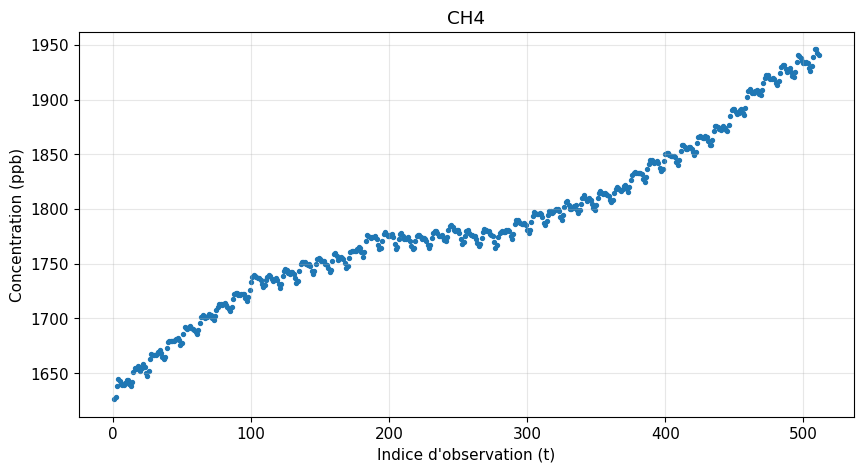

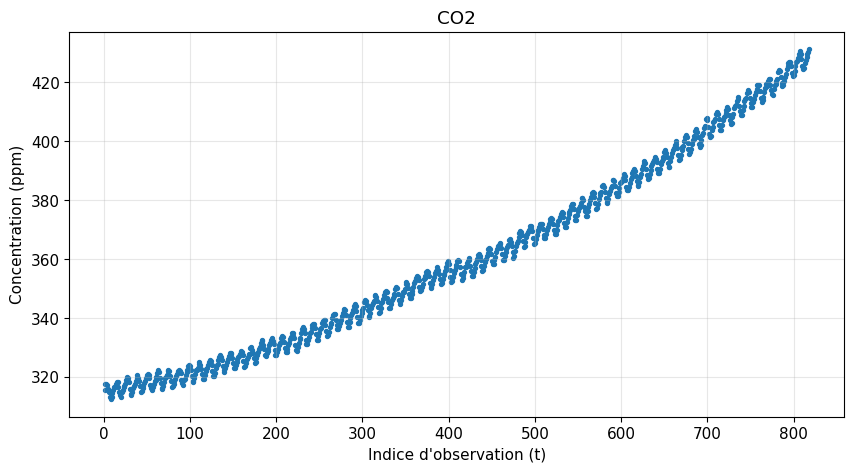

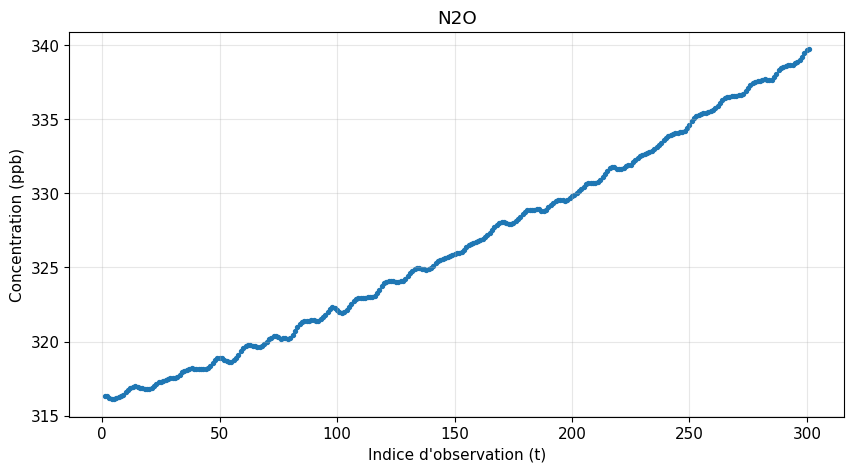

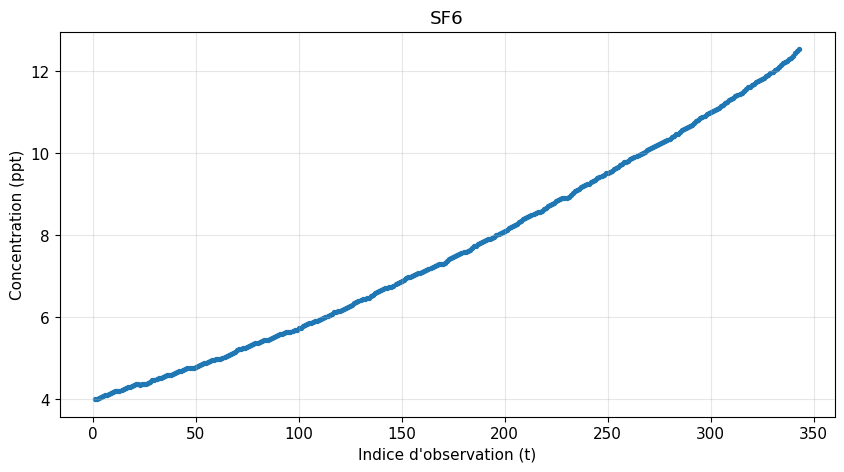

In [20]:
for nom_du_gaz, tableau_mensuel in donnees_par_gaz.items():
    plt.figure()
    plt.scatter(
        tableau_mensuel.index,
        tableau_mensuel["average"],
        s=8,
    )
    plt.xlabel("Indice d'observation (t)")
    plt.ylabel("Concentration (" + unites_mesure[nom_du_gaz] + ")")
    plt.title(nom_du_gaz)
    plt.grid(True, alpha=0.3)
    plt.show()


Les 4 gaz augmentent avec le temps.

Pour le **CO2** et le **CH4** on voit clairement des variations chaque année. C'est les saisons la concentration varie selon les mois.

Pour le **N2O** et le **SF6**, la courbe varie de façon régulière, sans vagues nettes donc pas de saisons visible.


## Questions 5 Décomposition additive (CO2 et CH4)

On écrit : concentration du mois t = tendance + effet saisonnier.

Étapes :
1. Moyenne mobile d'ordre 6 pour lisser la série
2. écart_saisonnier = concentration - série_lissée
3. coefficient mensuel = moyenne des écarts pour chaque mois (1 à 12)
4. coefficient corrigé = coefficient - moyenne des 12 coefficients
5. série corrigée = concentration - coefficient corrigé du mois
6. régression linéaire sur la série corrigée = tendance
7. prévision = tendance + coefficient corrigé


In [33]:
def calculer_moyenne_mobile(valeurs_mesurees):
    nombre_observations = len(valeurs_mesurees)
    serie_lissee = np.full(nombre_observations, np.nan)

    for indice in range(6, nombre_observations - 6):
        serie_lissee[indice] = (
            0.5 * valeurs_mesurees[indice - 6]
            + valeurs_mesurees[indice - 5]
            + valeurs_mesurees[indice - 4]
            + valeurs_mesurees[indice - 3]
            + valeurs_mesurees[indice - 2]
            + valeurs_mesurees[indice - 1]
            + valeurs_mesurees[indice]
            + valeurs_mesurees[indice + 1]
            + valeurs_mesurees[indice + 2]
            + valeurs_mesurees[indice + 3]
            + valeurs_mesurees[indice + 4]
            + valeurs_mesurees[indice + 5]
            + 0.5 * valeurs_mesurees[indice + 6]
        ) / 12

    return serie_lissee


def calculer_coefficients_mensuels(valeurs_ecart, numeros_mois):
    coefficients = {}
    for numero_mois in range(1, 13):
        valeurs_du_mois = valeurs_ecart[numeros_mois == numero_mois]
        valeurs_du_mois = valeurs_du_mois[~np.isnan(valeurs_du_mois)]
        coefficients[numero_mois] = np.mean(valeurs_du_mois)
    return coefficients


def decomposition_additive(nom_du_gaz):
    tableau_mensuel = donnees_par_gaz[nom_du_gaz]
    concentrations = tableau_mensuel["average"].values
    numeros_mois = tableau_mensuel["month"].values
    nombre_observations = len(concentrations)
    indices_observation = np.arange(1, nombre_observations + 1)

    serie_lissee = calculer_moyenne_mobile(concentrations)
    ecarts_saisonniers = concentrations - serie_lissee

    coefficients_mensuels = calculer_coefficients_mensuels(ecarts_saisonniers, numeros_mois)
    moyenne_des_coefficients = np.mean(list(coefficients_mensuels.values()))
    coefficients_corriges = {
        numero_mois: coefficients_mensuels[numero_mois] - moyenne_des_coefficients
        for numero_mois in range(1, 13)
    }

    serie_corrigee = np.array(
        [
            concentrations[i] - coefficients_corriges[numeros_mois[i]]
            for i in range(nombre_observations)
        ]
    )

    ordonnee_origine, pente, correlation = calculer_regression_lineaire(
        indices_observation, serie_corrigee
    )
    valeurs_tendance = ordonnee_origine + pente * indices_observation

    return {
        "concentrations": concentrations,
        "indices_observation": indices_observation,
        "numeros_mois": numeros_mois,
        "serie_lissee": serie_lissee,
        "ecarts_saisonniers": ecarts_saisonniers,
        "coefficients_mensuels": coefficients_mensuels,
        "coefficients_corriges": coefficients_corriges,
        "serie_corrigee": serie_corrigee,
        "ordonnee_origine": ordonnee_origine,
        "pente": pente,
        "correlation": correlation,
        "valeurs_tendance": valeurs_tendance,
        "nombre_observations": nombre_observations,
    }


### Moyenne mobile — pourquoi certains mois manquent ?

Pour calculer la valeur lissée au mois t, il faut les mesures de t-6 à t+6.
Donc il faut 6 mois avant et 6 mois après.

Impossible pour les **6 premiers** mois et les **6 derniers** mois de la série.

La moyenne mobile **lisse** la courbe : elle enlève les variations rapides pour garder la tendance de fond. On parle de **série lissée** parce que la courbe devient plus régulière.

**écart_saisonnier = concentration - série_lissée** donne ce qu'il reste après avoir enlevé la tendance lissée. C'est surtout l'effet saisonnier.

Les coefficients mensuels disent de combien chaque mois est en moyenne au-dessus ou en dessous du reste.

Les coefficients corrigés sont ajustés pour que leur somme vaille 0 : la saisonnalité ne change pas le niveau global, elle déplace seulement les valeurs d'un mois à l'autre.

La série corrigée enlève la saisonnalité. Il reste surtout la tendance (la montée dans le temps).

La droite de régression sur cette série = la **tendance** : l'augmentation moyenne par mois.


=== CO2 ===
Mois sans moyenne mobile : indice 1..6 et indice 813 .. 818
Coefficients mensuels corrigés :
  mois 1 : 0.081
  mois 2 : 0.728
  mois 3 : 1.434
  mois 4 : 2.588
  mois 5 : 3.037
  mois 6 : 2.335
  mois 7 : 0.658
  mois 8 : -1.524
  mois 9 : -3.176
  mois 10 : -3.251
  mois 11 : -2.049
  mois 12 : -0.861
Tendance : concentration = 304.1928 + 0.13877 * indice
Corrélation r = 0.9897



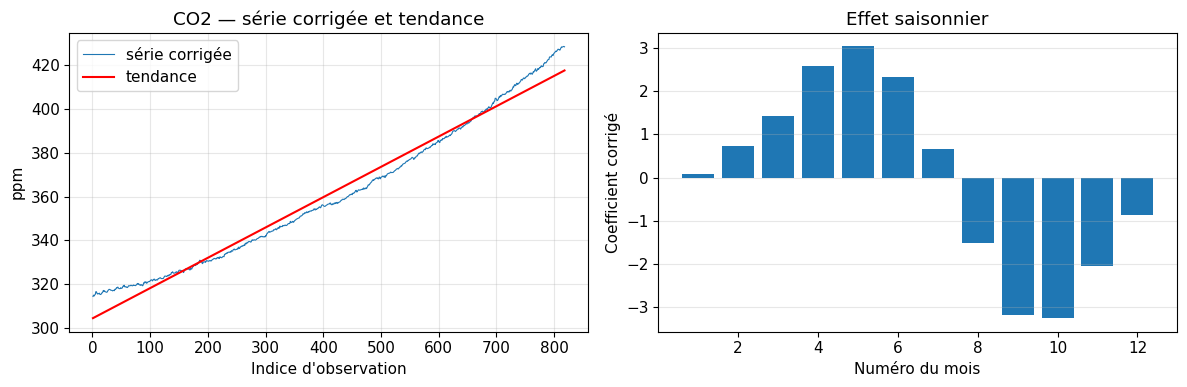

=== CH4 ===
Mois sans moyenne mobile : indice 1..6 et indice 506 .. 511
Coefficients mensuels corrigés :
  mois 1 : 2.156
  mois 2 : 1.079
  mois 3 : 1.267
  mois 4 : 1.177
  mois 5 : -1.001
  mois 6 : -5.477
  mois 7 : -8.768
  mois 8 : -6.081
  mois 9 : 0.631
  mois 10 : 5.057
  mois 11 : 5.669
  mois 12 : 4.291
Tendance : concentration = 1660.7769 + 0.48714 * indice
Corrélation r = 0.9736



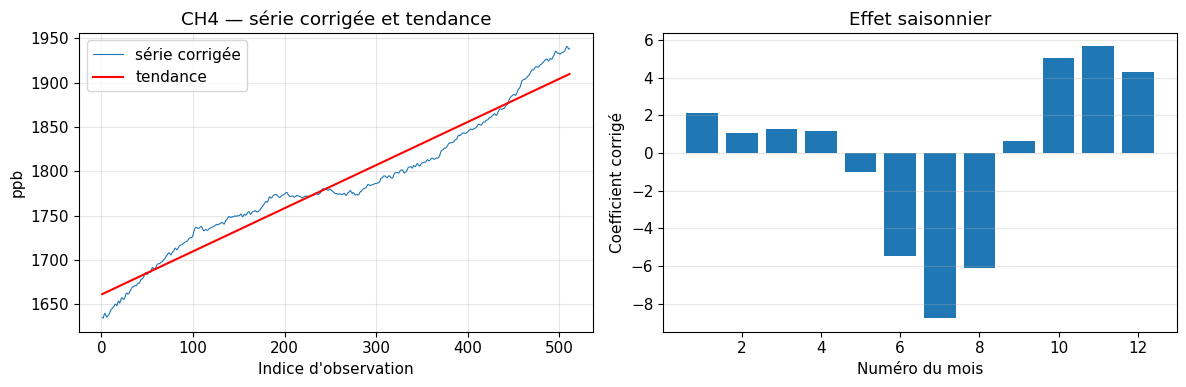

In [22]:
gaz_avec_saisonnalite = ["CO2", "CH4"]
resultats_decomposition_additive = {}

for nom_du_gaz in gaz_avec_saisonnalite:
    resultat = decomposition_additive(nom_du_gaz)
    resultats_decomposition_additive[nom_du_gaz] = resultat
    nombre_observations = resultat["nombre_observations"]

    print("===", nom_du_gaz, "===")
    print(
        "Mois sans moyenne mobile : indice 1..6 et indice",
        nombre_observations - 5,
        "..",
        nombre_observations,
    )
    print("Coefficients mensuels corrigés :")
    for numero_mois in range(1, 13):
        print("  mois", numero_mois, ":", round(resultat["coefficients_corriges"][numero_mois], 3))
    print(
        "Tendance : concentration =",
        round(resultat["ordonnee_origine"], 4),
        "+",
        round(resultat["pente"], 5),
        "* indice",
    )
    print("Corrélation r =", round(resultat["correlation"], 4))
    print()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(
        resultat["indices_observation"],
        resultat["serie_corrigee"],
        label="série corrigée",
        linewidth=0.8,
    )
    plt.plot(
        resultat["indices_observation"],
        resultat["valeurs_tendance"],
        "r-",
        label="tendance",
    )
    plt.xlabel("Indice d'observation")
    plt.ylabel(unites_mesure[nom_du_gaz])
    plt.title(nom_du_gaz + " — série corrigée et tendance")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    numeros_mois = list(range(1, 13))
    plt.bar(
        numeros_mois,
        [resultat["coefficients_corriges"][m] for m in numeros_mois],
    )
    plt.xlabel("Numéro du mois")
    plt.ylabel("Coefficient corrigé")
    plt.title("Effet saisonnier")
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()


### Prévisions additives (2 prochaines années)

Pour un mois futur : **prévision = valeur de la tendance + coefficient mensuel corrigé**.

On suppose que la tendance continue comme avant et que le motif saisonnier se répète chaque année.


In [23]:
def previsions_additive(nom_du_gaz, nombre_mois_a_prevoir=24):
    resultat = resultats_decomposition_additive[nom_du_gaz]
    tableau_complet = donnees_completes_par_gaz[nom_du_gaz]

    annee_courante = int(tableau_complet["year"].iloc[-1])
    mois_courant = int(tableau_complet["month"].iloc[-1])
    dernier_indice = resultat["nombre_observations"]

    lignes_previsions = []
    for decalage in range(1, nombre_mois_a_prevoir + 1):
        mois_courant = mois_courant + 1
        if mois_courant > 12:
            mois_courant = 1
            annee_courante = annee_courante + 1

        indice_futur = dernier_indice + decalage
        valeur_tendance = resultat["ordonnee_origine"] + resultat["pente"] * indice_futur
        prevision = valeur_tendance + resultat["coefficients_corriges"][mois_courant]

        lignes_previsions.append(
            {
                "annee": annee_courante,
                "mois": mois_courant,
                "indice_observation": indice_futur,
                "prevision": round(prevision, 2),
            }
        )

    return pd.DataFrame(lignes_previsions)


for nom_du_gaz in gaz_avec_saisonnalite:
    print("=== Prévisions", nom_du_gaz, "===")
    print(previsions_additive(nom_du_gaz).to_string(index=False))
    print()


=== Prévisions CO2 ===
 annee  mois  indice_observation  prevision
  2026     5                 819     420.88
  2026     6                 820     420.32
  2026     7                 821     418.78
  2026     8                 822     416.74
  2026     9                 823     415.23
  2026    10                 824     415.29
  2026    11                 825     416.63
  2026    12                 826     417.96
  2027     1                 827     419.04
  2027     2                 828     419.82
  2027     3                 829     420.67
  2027     4                 830     421.96
  2027     5                 831     422.55
  2027     6                 832     421.99
  2027     7                 833     420.45
  2027     8                 834     418.40
  2027     9                 835     416.89
  2027    10                 836     416.95
  2027    11                 837     418.29
  2027    12                 838     419.62
  2028     1                 839     420.70
  2028   

### D'où vient la saisonnalité ?

**CO2** : les plantes absorbent du CO2 au printemps/été (photosynthèse) et en libèrent en automne/hiver. L'hémisphère nord a beaucoup de végétation, donc on voit un cycle annuel.

**CH4** : variations liées à l'humidité des sols, aux zones humides et à l'activité humaine selon les saisons.

En résumé : ce sont surtout les cycles naturels (végétation, sols) qui créent ces « vagues » chaque année, en plus de la hausse de fond.


## Question 6 et 7 décomposition multiplicative (CO2 et CH4)

On écrit : concentration du mois t = tendance × effet saisonnier.

Même idée que l'additive, mais avec des divisions et des produits.


=== CO2 (multiplicatif) ===
Coefficients mensuels corrigés (rapport) :
  mois 1 : 1.0002
  mois 2 : 1.002
  mois 3 : 1.004
  mois 4 : 1.0072
  mois 5 : 1.0084
  mois 6 : 1.0065
  mois 7 : 1.0019
  mois 8 : 0.9958
  mois 9 : 0.9912
  mois 10 : 0.9909
  mois 11 : 0.9943
  mois 12 : 0.9976
Tendance : concentration = 304.1943 + 0.13877 * indice



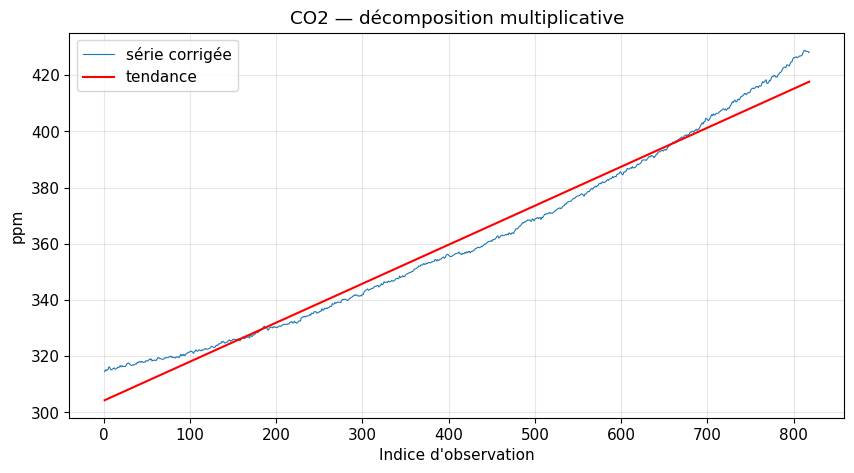

=== CH4 (multiplicatif) ===
Coefficients mensuels corrigés (rapport) :
  mois 1 : 1.0012
  mois 2 : 1.0006
  mois 3 : 1.0007
  mois 4 : 1.0007
  mois 5 : 0.9994
  mois 6 : 0.9969
  mois 7 : 0.9951
  mois 8 : 0.9966
  mois 9 : 1.0003
  mois 10 : 1.0028
  mois 11 : 1.0032
  mois 12 : 1.0024
Tendance : concentration = 1660.7771 + 0.48714 * indice



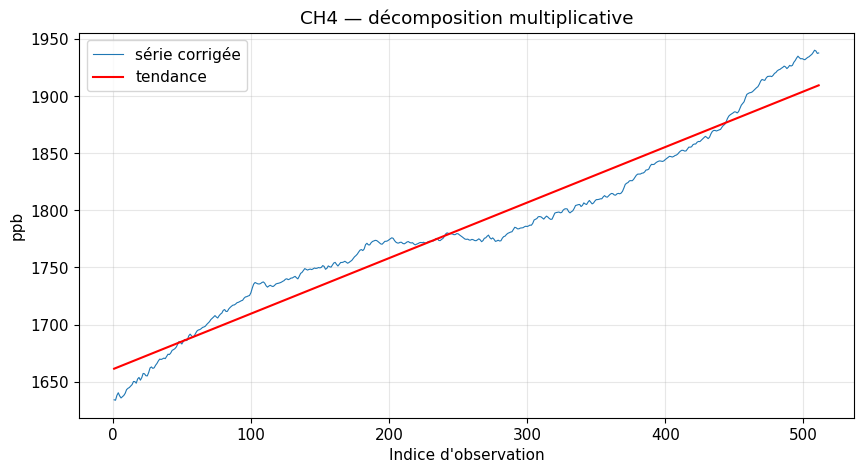

In [24]:
def decomposition_multiplicative(nom_du_gaz):
    tableau_mensuel = donnees_par_gaz[nom_du_gaz]
    concentrations = tableau_mensuel["average"].values
    numeros_mois = tableau_mensuel["month"].values
    nombre_observations = len(concentrations)
    indices_observation = np.arange(1, nombre_observations + 1)

    serie_lissee = calculer_moyenne_mobile(concentrations)
    rapports_saisonniers = concentrations / serie_lissee

    coefficients_mensuels = calculer_coefficients_mensuels(rapports_saisonniers, numeros_mois)
    moyenne_des_coefficients = np.mean(list(coefficients_mensuels.values()))
    coefficients_corriges = {
        numero_mois: coefficients_mensuels[numero_mois] / moyenne_des_coefficients
        for numero_mois in range(1, 13)
    }

    serie_corrigee = np.array(
        [
            concentrations[i] / coefficients_corriges[numeros_mois[i]]
            for i in range(nombre_observations)
        ]
    )

    ordonnee_origine, pente, correlation = calculer_regression_lineaire(
        indices_observation, serie_corrigee
    )
    valeurs_tendance = ordonnee_origine + pente * indices_observation

    return {
        "concentrations": concentrations,
        "indices_observation": indices_observation,
        "numeros_mois": numeros_mois,
        "serie_lissee": serie_lissee,
        "rapports_saisonniers": rapports_saisonniers,
        "coefficients_mensuels": coefficients_mensuels,
        "coefficients_corriges": coefficients_corriges,
        "serie_corrigee": serie_corrigee,
        "ordonnee_origine": ordonnee_origine,
        "pente": pente,
        "correlation": correlation,
        "valeurs_tendance": valeurs_tendance,
        "nombre_observations": nombre_observations,
    }


resultats_decomposition_multiplicative = {}

for nom_du_gaz in gaz_avec_saisonnalite:
    resultat = decomposition_multiplicative(nom_du_gaz)
    resultats_decomposition_multiplicative[nom_du_gaz] = resultat

    print("===", nom_du_gaz, "(multiplicatif) ===")
    print("Coefficients mensuels corrigés (rapport) :")
    for numero_mois in range(1, 13):
        print("  mois", numero_mois, ":", round(resultat["coefficients_corriges"][numero_mois], 4))
    print(
        "Tendance : concentration =",
        round(resultat["ordonnee_origine"], 4),
        "+",
        round(resultat["pente"], 5),
        "* indice",
    )
    print()

    plt.figure()
    plt.plot(
        resultat["indices_observation"],
        resultat["serie_corrigee"],
        label="série corrigée",
        linewidth=0.8,
    )
    plt.plot(
        resultat["indices_observation"],
        resultat["valeurs_tendance"],
        "r-",
        label="tendance",
    )
    plt.xlabel("Indice d'observation")
    plt.ylabel(unites_mesure[nom_du_gaz])
    plt.title(nom_du_gaz + " — décomposition multiplicative")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [25]:
def previsions_multiplicative(nom_du_gaz, nombre_mois_a_prevoir=24):
    resultat = resultats_decomposition_multiplicative[nom_du_gaz]
    tableau_complet = donnees_completes_par_gaz[nom_du_gaz]

    annee_courante = int(tableau_complet["year"].iloc[-1])
    mois_courant = int(tableau_complet["month"].iloc[-1])
    dernier_indice = resultat["nombre_observations"]

    lignes_previsions = []
    for decalage in range(1, nombre_mois_a_prevoir + 1):
        mois_courant = mois_courant + 1
        if mois_courant > 12:
            mois_courant = 1
            annee_courante = annee_courante + 1

        indice_futur = dernier_indice + decalage
        valeur_tendance = resultat["ordonnee_origine"] + resultat["pente"] * indice_futur
        prevision = valeur_tendance * resultat["coefficients_corriges"][mois_courant]

        lignes_previsions.append(
            {
                "annee": annee_courante,
                "mois": mois_courant,
                "indice_observation": indice_futur,
                "prevision": round(prevision, 2),
            }
        )

    return pd.DataFrame(lignes_previsions)


for nom_du_gaz in gaz_avec_saisonnalite:
    print("=== Prévisions multiplicatives", nom_du_gaz, "===")
    print(previsions_multiplicative(nom_du_gaz).head(6).to_string(index=False))
    print("...")
    print()


=== Prévisions multiplicatives CO2 ===
 annee  mois  indice_observation  prevision
  2026     5                 819     421.38
  2026     6                 820     420.70
  2026     7                 821     418.91
  2026     8                 822     416.51
  2026     9                 823     414.71
  2026    10                 824     414.75
...

=== Prévisions multiplicatives CH4 ===
 annee  mois  indice_observation  prevision
  2026     2                 512    1911.36
  2026     3                 513    1912.05
  2026     4                 514    1912.44
  2026     5                 515    1910.60
  2026     6                 516    1906.29
  2026     7                 517    1903.24
...



### Comparaison additive vs multiplicative

**Additive** : on ajoute/enlève un nombre fixe chaque mois. La taille des vagues ne change pas avec le temps.

**Multiplicative** : on multiplie par un facteur. Les vagues grandissent si la concentration monte.

Ici les deux marchent, mais le **modèle multiplicatif** est souvent plus adapté au CO2 et au CH4 : quand la concentration augmente, l'amplitude saisonnière augmente aussi.

Pour **rapport_saisonnier = concentration / série_lissée** : si le rapport > 1, le mois est au-dessus de la tendance lissée. Si < 1, en dessous.


## Question 8 Régression linéaire (N2O et SF6)

Pas de saisons visible, donc on ajuste une droite directement sur les données.


=== N2O ===
Coefficient de corrélation r = 0.9966
Droite : concentration = 314.6369 + 0.07915 * indice



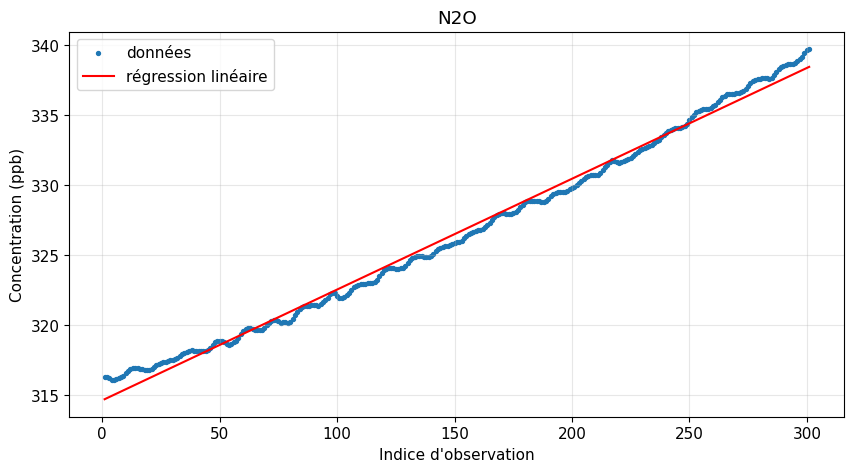

=== SF6 ===
Coefficient de corrélation r = 0.9948
Droite : concentration = 3.4312 + 0.02469 * indice



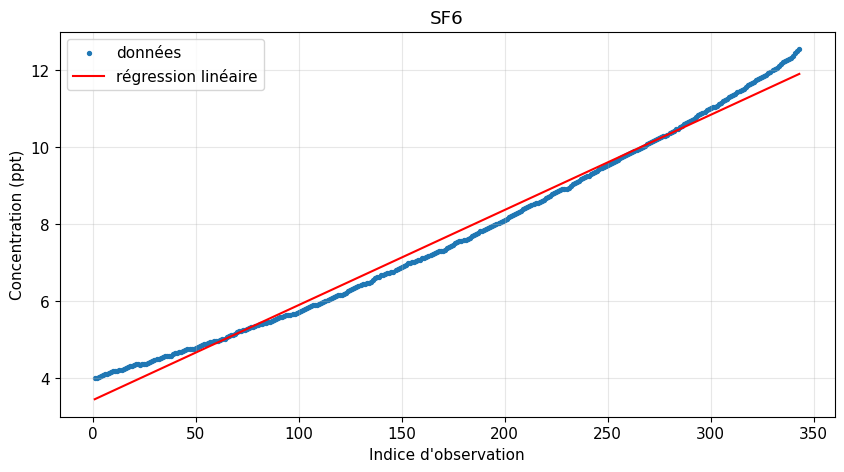

In [26]:
gaz_sans_saisonnalite = ["N2O", "SF6"]
regressions_lineaires = {}

for nom_du_gaz in gaz_sans_saisonnalite:
    tableau_mensuel = donnees_par_gaz[nom_du_gaz]
    indices_observation = tableau_mensuel.index.values
    concentrations = tableau_mensuel["average"].values

    coefficient_correlation = np.corrcoef(indices_observation, concentrations)[0, 1]
    ordonnee_origine, pente, _ = calculer_regression_lineaire(
        indices_observation, concentrations
    )
    concentrations_predites = ordonnee_origine + pente * indices_observation

    regressions_lineaires[nom_du_gaz] = {
        "ordonnee_origine": ordonnee_origine,
        "pente": pente,
        "correlation": coefficient_correlation,
    }

    print("===", nom_du_gaz, "===")
    print("Coefficient de corrélation r =", round(coefficient_correlation, 4))
    print(
        "Droite : concentration =",
        round(ordonnee_origine, 4),
        "+",
        round(pente, 5),
        "* indice",
    )
    print()

    plt.figure()
    plt.scatter(indices_observation, concentrations, s=8, label="données")
    plt.plot(indices_observation, concentrations_predites, "r-", label="régression linéaire")
    plt.xlabel("Indice d'observation")
    plt.ylabel("Concentration (" + unites_mesure[nom_du_gaz] + ")")
    plt.title(nom_du_gaz)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [27]:
def previsions_lineaire(nom_du_gaz, nombre_mois_a_prevoir=24):
    regression = regressions_lineaires[nom_du_gaz]
    tableau_complet = donnees_completes_par_gaz[nom_du_gaz]

    annee_courante = int(tableau_complet["year"].iloc[-1])
    mois_courant = int(tableau_complet["month"].iloc[-1])
    dernier_indice = len(donnees_par_gaz[nom_du_gaz])

    lignes_previsions = []
    for decalage in range(1, nombre_mois_a_prevoir + 1):
        mois_courant = mois_courant + 1
        if mois_courant > 12:
            mois_courant = 1
            annee_courante = annee_courante + 1

        indice_futur = dernier_indice + decalage
        prevision = regression["ordonnee_origine"] + regression["pente"] * indice_futur

        lignes_previsions.append(
            {
                "annee": annee_courante,
                "mois": mois_courant,
                "indice_observation": indice_futur,
                "prevision": round(prevision, 3),
            }
        )

    return pd.DataFrame(lignes_previsions)


for nom_du_gaz in gaz_sans_saisonnalite:
    print("=== Prévisions linéaires", nom_du_gaz, "===")
    print(previsions_lineaire(nom_du_gaz).to_string(index=False))
    print()


=== Prévisions linéaires N2O ===
 annee  mois  indice_observation  prevision
  2026     2                 302    338.539
  2026     3                 303    338.618
  2026     4                 304    338.697
  2026     5                 305    338.777
  2026     6                 306    338.856
  2026     7                 307    338.935
  2026     8                 308    339.014
  2026     9                 309    339.093
  2026    10                 310    339.172
  2026    11                 311    339.251
  2026    12                 312    339.331
  2027     1                 313    339.410
  2027     2                 314    339.489
  2027     3                 315    339.568
  2027     4                 316    339.647
  2027     5                 317    339.726
  2027     6                 318    339.805
  2027     7                 319    339.885
  2027     8                 320    339.964
  2027     9                 321    340.043
  2027    10                 322    340.122

## Question 8.2 Régression exponentielle (N2O et SF6)

On suppose que la concentration croît de façon exponentielle : concentration = A × e^(k×t).

En pratique on fait une régression sur ln(concentration) = ln(A) + k×t, puis on repasse en exponentielle.


=== N2O (exponentiel) ===
Coefficient de corrélation (sur ln y) r = 0.9972
Modèle : concentration = 314.7965 * exp( 0.00024 * indice)



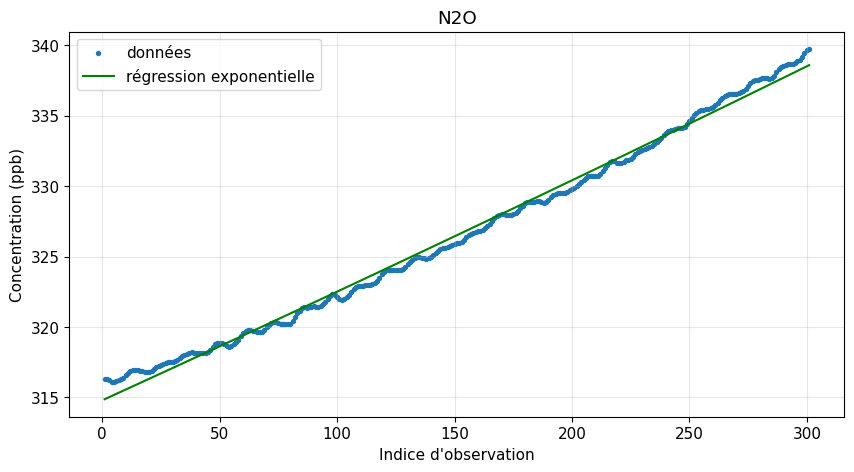

=== SF6 (exponentiel) ===
Coefficient de corrélation (sur ln y) r = 0.9991
Modèle : concentration = 4.11 * exp( 0.00332 * indice)



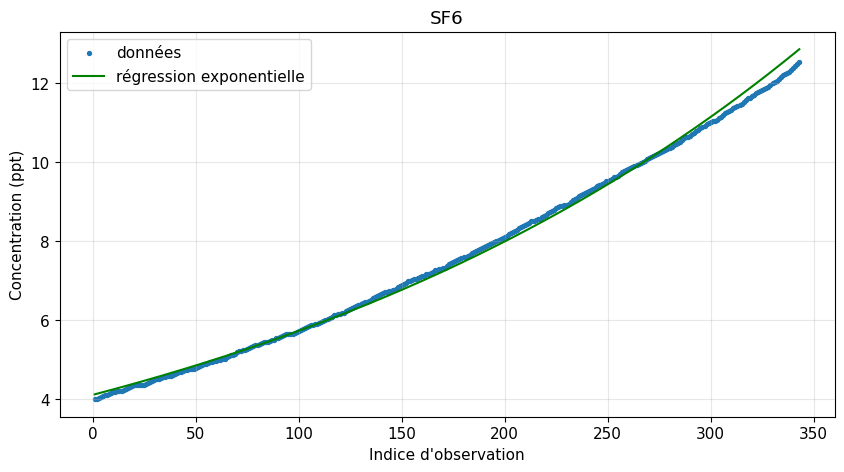

In [28]:
regressions_exponentielles = {}

for nom_du_gaz in gaz_sans_saisonnalite:
    tableau_mensuel = donnees_par_gaz[nom_du_gaz]
    indices_observation = tableau_mensuel.index.values
    concentrations = tableau_mensuel["average"].values
    log_concentrations = np.log(concentrations)

    coefficient_correlation = np.corrcoef(indices_observation, log_concentrations)[0, 1]
    ordonnee_origine, pente, _ = calculer_regression_lineaire(
        indices_observation, log_concentrations
    )
    courbe_exponentielle = np.exp(ordonnee_origine + pente * indices_observation)

    regressions_exponentielles[nom_du_gaz] = {
        "ordonnee_origine": ordonnee_origine,
        "pente": pente,
        "correlation": coefficient_correlation,
    }

    print("===", nom_du_gaz, "(exponentiel) ===")
    print("Coefficient de corrélation (sur ln y) r =", round(coefficient_correlation, 4))
    print(
        "Modèle : concentration =",
        round(np.exp(ordonnee_origine), 4),
        "* exp(",
        round(pente, 5),
        "* indice)",
    )
    print()

    plt.figure()
    plt.scatter(indices_observation, concentrations, s=8, label="données")
    plt.plot(indices_observation, courbe_exponentielle, "g-", label="régression exponentielle")
    plt.xlabel("Indice d'observation")
    plt.ylabel("Concentration (" + unites_mesure[nom_du_gaz] + ")")
    plt.title(nom_du_gaz)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [29]:
def previsions_exponentielle(nom_du_gaz, nombre_mois_a_prevoir=24):
    regression = regressions_exponentielles[nom_du_gaz]
    tableau_complet = donnees_completes_par_gaz[nom_du_gaz]

    annee_courante = int(tableau_complet["year"].iloc[-1])
    mois_courant = int(tableau_complet["month"].iloc[-1])
    dernier_indice = len(donnees_par_gaz[nom_du_gaz])

    lignes_previsions = []
    for decalage in range(1, nombre_mois_a_prevoir + 1):
        mois_courant = mois_courant + 1
        if mois_courant > 12:
            mois_courant = 1
            annee_courante = annee_courante + 1

        indice_futur = dernier_indice + decalage
        prevision = np.exp(regression["ordonnee_origine"] + regression["pente"] * indice_futur)

        lignes_previsions.append(
            {
                "annee": annee_courante,
                "mois": mois_courant,
                "indice_observation": indice_futur,
                "prevision": round(prevision, 3),
            }
        )

    return pd.DataFrame(lignes_previsions)


for nom_du_gaz in gaz_sans_saisonnalite:
    print("=== Prévisions exponentielles", nom_du_gaz, "===")
    print(previsions_exponentielle(nom_du_gaz).to_string(index=False))
    print()


=== Prévisions exponentielles N2O ===
 annee  mois  indice_observation  prevision
  2026     2                 302    338.670
  2026     3                 303    338.752
  2026     4                 304    338.834
  2026     5                 305    338.916
  2026     6                 306    338.998
  2026     7                 307    339.080
  2026     8                 308    339.163
  2026     9                 309    339.245
  2026    10                 310    339.327
  2026    11                 311    339.409
  2026    12                 312    339.491
  2027     1                 313    339.573
  2027     2                 314    339.655
  2027     3                 315    339.738
  2027     4                 316    339.820
  2027     5                 317    339.902
  2027     6                 318    339.984
  2027     7                 319    340.067
  2027     8                 320    340.149
  2027     9                 321    340.231
  2027    10                 322    34

In [30]:
for nom_du_gaz in gaz_sans_saisonnalite:
    tableau_mensuel = donnees_par_gaz[nom_du_gaz]
    indices_observation = tableau_mensuel.index.values
    concentrations = tableau_mensuel["average"].values

    regression_lineaire = regressions_lineaires[nom_du_gaz]
    regression_exponentielle = regressions_exponentielles[nom_du_gaz]

    concentrations_lineaires = (
        regression_lineaire["ordonnee_origine"]
        + regression_lineaire["pente"] * indices_observation
    )
    concentrations_exponentielles = np.exp(
        regression_exponentielle["ordonnee_origine"]
        + regression_exponentielle["pente"] * indices_observation
    )

    erreur_lineaire = np.mean((concentrations - concentrations_lineaires) ** 2)
    erreur_exponentielle = np.mean((concentrations - concentrations_exponentielles) ** 2)

    print(
        nom_du_gaz,
        "— erreur moyenne au carré : linéaire =",
        round(erreur_lineaire, 4),
        ", exponentiel =",
        round(erreur_exponentielle, 4),
    )
    if erreur_exponentielle < erreur_lineaire:
        print("  -> le modèle exponentiel colle un peu mieux")
    else:
        print("  -> le modèle linéaire colle un peu mieux")
    print()


N2O — erreur moyenne au carré : linéaire = 0.3263 , exponentiel = 0.2616
  -> le modèle exponentiel colle un peu mieux

SF6 — erreur moyenne au carré : linéaire = 0.0623 , exponentiel = 0.016
  -> le modèle exponentiel colle un peu mieux



Le **N2O** monte assez régulièrement : le linéaire et l'exponentiel sont proches. Le linéaire suffit souvent.

Le **SF6** augmente de plus en plus vite : l'exponentiel suit mieux la courbure. Pour le SF6 le modèle exponentiel est en général plus pertinent.

Un coefficient de corrélation proche de 1 (en valeur absolue) signifie une forte liaison entre le temps et la concentration.


## Question 9 Données annuelles (CO2 et CH4)

On regroupe les moyennes par année pour enlever la saisonnalité et voir la tendance sur le long terme.


=== CO2 annuel ===
   year     average
1  1958  315.237000
2  1959  315.981667
3  1960  316.908333
...
Nombre d'années : 69
Corrélation linéaire r = 0.9895
Droite : concentration = 303.02 + 1.673 * indice
Corrélation exponentielle r (ln y) = 0.9944



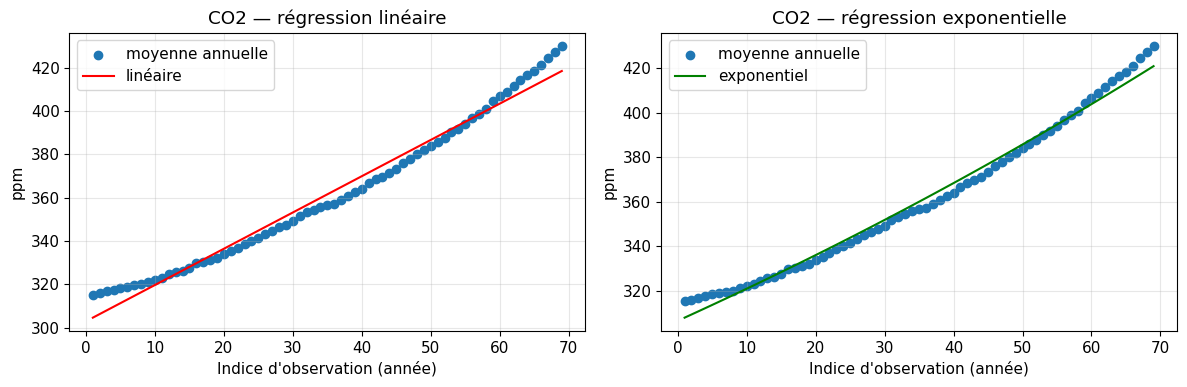

=== CH4 annuel ===
   year      average
1  1983  1636.561667
2  1984  1645.011667
3  1985  1657.371667
...
Nombre d'années : 44
Corrélation linéaire r = 0.9756
Droite : concentration = 1652.97 + 5.958 * indice
Corrélation exponentielle r (ln y) = 0.9766



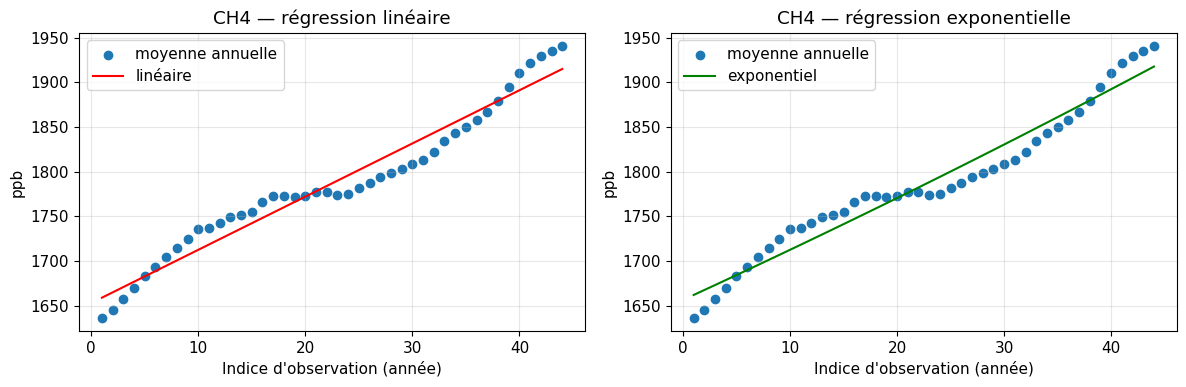

In [31]:
regressions_annuelles_lineaires = {}
regressions_annuelles_exponentielles = {}
donnees_annuelles_par_gaz = {}

for nom_du_gaz in gaz_avec_saisonnalite:
    tableau_complet = donnees_completes_par_gaz[nom_du_gaz]
    tableau_annuel = tableau_complet.groupby("year")["average"].mean().reset_index()
    tableau_annuel.index = range(1, len(tableau_annuel) + 1)
    donnees_annuelles_par_gaz[nom_du_gaz] = tableau_annuel

    indices_observation = tableau_annuel.index.values
    concentrations_annuelles = tableau_annuel["average"].values

    correlation_lineaire = np.corrcoef(indices_observation, concentrations_annuelles)[0, 1]
    ordonnee_origine_lin, pente_lin, _ = calculer_regression_lineaire(
        indices_observation, concentrations_annuelles
    )
    droite_lineaire = ordonnee_origine_lin + pente_lin * indices_observation
    regressions_annuelles_lineaires[nom_du_gaz] = {
        "ordonnee_origine": ordonnee_origine_lin,
        "pente": pente_lin,
        "correlation": correlation_lineaire,
        "nombre_annees": len(indices_observation),
    }

    log_concentrations = np.log(concentrations_annuelles)
    correlation_exponentielle = np.corrcoef(indices_observation, log_concentrations)[0, 1]
    ordonnee_origine_exp, pente_exp, _ = calculer_regression_lineaire(
        indices_observation, log_concentrations
    )
    courbe_exponentielle = np.exp(ordonnee_origine_exp + pente_exp * indices_observation)
    regressions_annuelles_exponentielles[nom_du_gaz] = {
        "ordonnee_origine": ordonnee_origine_exp,
        "pente": pente_exp,
        "correlation": correlation_exponentielle,
    }

    print("===", nom_du_gaz, "annuel ===")
    print(tableau_annuel.head(3))
    print("...")
    print("Nombre d'années :", len(tableau_annuel))
    print("Corrélation linéaire r =", round(correlation_lineaire, 4))
    print(
        "Droite : concentration =",
        round(ordonnee_origine_lin, 2),
        "+",
        round(pente_lin, 3),
        "* indice",
    )
    print("Corrélation exponentielle r (ln y) =", round(correlation_exponentielle, 4))
    print()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(indices_observation, concentrations_annuelles, label="moyenne annuelle")
    plt.plot(indices_observation, droite_lineaire, "r-", label="linéaire")
    plt.xlabel("Indice d'observation (année)")
    plt.ylabel(unites_mesure[nom_du_gaz])
    plt.title(nom_du_gaz + " — régression linéaire")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(indices_observation, concentrations_annuelles, label="moyenne annuelle")
    plt.plot(indices_observation, courbe_exponentielle, "g-", label="exponentiel")
    plt.xlabel("Indice d'observation (année)")
    plt.ylabel(unites_mesure[nom_du_gaz])
    plt.title(nom_du_gaz + " — régression exponentielle")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [32]:
for nom_du_gaz in gaz_avec_saisonnalite:
    tableau_annuel = donnees_annuelles_par_gaz[nom_du_gaz]
    derniere_annee = int(tableau_annuel["year"].iloc[-1])
    dernier_indice = regressions_annuelles_lineaires[nom_du_gaz]["nombre_annees"]

    print("=== Prévisions annuelles", nom_du_gaz, "===")
    for decalage in range(1, 3):
        annee_future = derniere_annee + decalage
        indice_futur = dernier_indice + decalage

        regression_lin = regressions_annuelles_lineaires[nom_du_gaz]
        regression_exp = regressions_annuelles_exponentielles[nom_du_gaz]

        prevision_lineaire = regression_lin["ordonnee_origine"] + regression_lin["pente"] * indice_futur
        prevision_exponentielle = np.exp(
            regression_exp["ordonnee_origine"] + regression_exp["pente"] * indice_futur
        )

        print(
            " ",
            annee_future,
            "— linéaire :",
            round(prevision_lineaire, 2),
            unites_mesure[nom_du_gaz],
            "| exponentiel :",
            round(prevision_exponentielle, 2),
            unites_mesure[nom_du_gaz],
        )
    print()

    indices_observation = tableau_annuel.index.values
    concentrations_annuelles = tableau_annuel["average"].values

    regression_lin = regressions_annuelles_lineaires[nom_du_gaz]
    regression_exp = regressions_annuelles_exponentielles[nom_du_gaz]

    concentrations_lineaires = (
        regression_lin["ordonnee_origine"] + regression_lin["pente"] * indices_observation
    )
    concentrations_exponentielles = np.exp(
        regression_exp["ordonnee_origine"] + regression_exp["pente"] * indices_observation
    )

    erreur_lineaire = np.mean((concentrations_annuelles - concentrations_lineaires) ** 2)
    erreur_exponentielle = np.mean((concentrations_annuelles - concentrations_exponentielles) ** 2)

    print(
        "  Erreur moyenne au carré — linéaire :",
        round(erreur_lineaire, 4),
        "| exponentiel :",
        round(erreur_exponentielle, 4),
    )
    print()


=== Prévisions annuelles CO2 ===
  2027 — linéaire : 420.13 ppm | exponentiel : 422.87 ppm
  2028 — linéaire : 421.81 ppm | exponentiel : 424.82 ppm

  Erreur moyenne au carré — linéaire : 23.7087 | exponentiel : 12.5935

=== Prévisions annuelles CH4 ===
  2027 — linéaire : 1921.08 ppb | exponentiel : 1924.26 ppb
  2028 — linéaire : 1927.04 ppb | exponentiel : 1930.68 ppb

  Erreur moyenne au carré — linéaire : 290.3587 | exponentiel : 278.05



Sur les données annuelles, le CO2 et le CH4 montent de façon très régulière (r proche de 1).

Pour le **CO2**, le linéaire et l'exponentiel sont très proches sur cette période.

Pour le **CH4**, l'exponentiel peut parfois mieux coller si la croissance s'accélère.

Les prévisions annuelles prolongent simplement la tendance estimée sur les moyennes par année.
